# Post-recalibration `precursor_ppm` distributions: full 3x4 grid

Plots the *final*, post-correction `precursor_ppm` distributions from
`jobs/short_test_recal_grid.toml`'s real full-pipeline runs (3 precursor-selection
strategies x 4 correction models, 12 combos, each searching the entire
~649k-precursor pool with its own recalibrated tof2mz/tolerance) -- companion to
`recalibration_model_comparison.ipynb`'s `grid_summary` table, visualizing the same
12 combos' actual error distributions rather than just summary statistics.


In [1]:
import os
import subprocess
from pathlib import Path

REPO_ROOT = (Path.cwd() / "../../..").resolve()
os.chdir(REPO_ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from searchops.recalibration import filter_top_psms

FDR = 0.01


## Resolve result paths via `./nf outputs` (not hardcoded node hashes)

In [2]:
def nf_outputs(job_toml: str) -> dict[str, dict[str, str]]:
    """Parse `./nf outputs <job_toml>` into {combo_label: {output_name: result_path}}."""
    proc = subprocess.run(
        ["./nf", "outputs", job_toml],
        cwd=REPO_ROOT, capture_output=True, text=True, check=True,
    )
    combos: dict[str, dict[str, str]] = {}
    label = None
    for line in proc.stdout.splitlines():
        if not line.strip():
            continue
        if line.startswith("[") and line.endswith("]"):
            label = line[1:-1]
            combos[label] = {}
            continue
        key, rest = line.split("\t", 1)
        fields = dict(part.split("=", 1) for part in rest.split("\t"))
        combos[label][key] = fields["result"]
    return combos


def combo_label_parts(label: str) -> tuple[str, str]:
    # "short_test_recal_grid__recalibration_precursor_selection+X__recalibration+Y"
    parts = label.split("__")
    selection = next(p.split("+", 1)[1] for p in parts if p.startswith("recalibration_precursor_selection+"))
    model = next(p.split("+", 1)[1] for p in parts if p.startswith("recalibration+"))
    return selection, model


grid_combos = nf_outputs("jobs/short_test_recal_grid.toml")
SELECTIONS = ["top_k_intense", "random_5000", "argmax_nms"]
MODELS = ["global_median", "binned_median", "natural_cubic_spline", "xgboost_derivative_penalized"]

dfs = {}
for label, outputs in grid_combos.items():
    selection, model = combo_label_parts(label)
    dfs[(selection, model)] = filter_top_psms(REPO_ROOT / outputs["sage_results_tsv"], fdr=FDR)

{k: len(v) for k, v in dfs.items()}


{('top_k_intense', 'global_median'): 78000,
 ('top_k_intense', 'binned_median'): 79977,
 ('top_k_intense', 'natural_cubic_spline'): 80971,
 ('top_k_intense', 'xgboost_derivative_penalized'): 79796,
 ('random_5000', 'global_median'): 76697,
 ('random_5000', 'binned_median'): 79171,
 ('random_5000', 'natural_cubic_spline'): 76621,
 ('random_5000', 'xgboost_derivative_penalized'): 80948,
 ('argmax_nms', 'global_median'): 75582,
 ('argmax_nms', 'binned_median'): 74188,
 ('argmax_nms', 'natural_cubic_spline'): 76331,
 ('argmax_nms', 'xgboost_derivative_penalized'): 75889}

## 3x4 grid: one panel per (selection, model), post-correction `precursor_ppm` histogram

Dashed grey line at 0 (perfect calibration); solid colored line at the actual
median, annotated -- lets the systematic-offset differences from `grid_summary`
be seen directly as a shift of the whole distribution, not just a number.


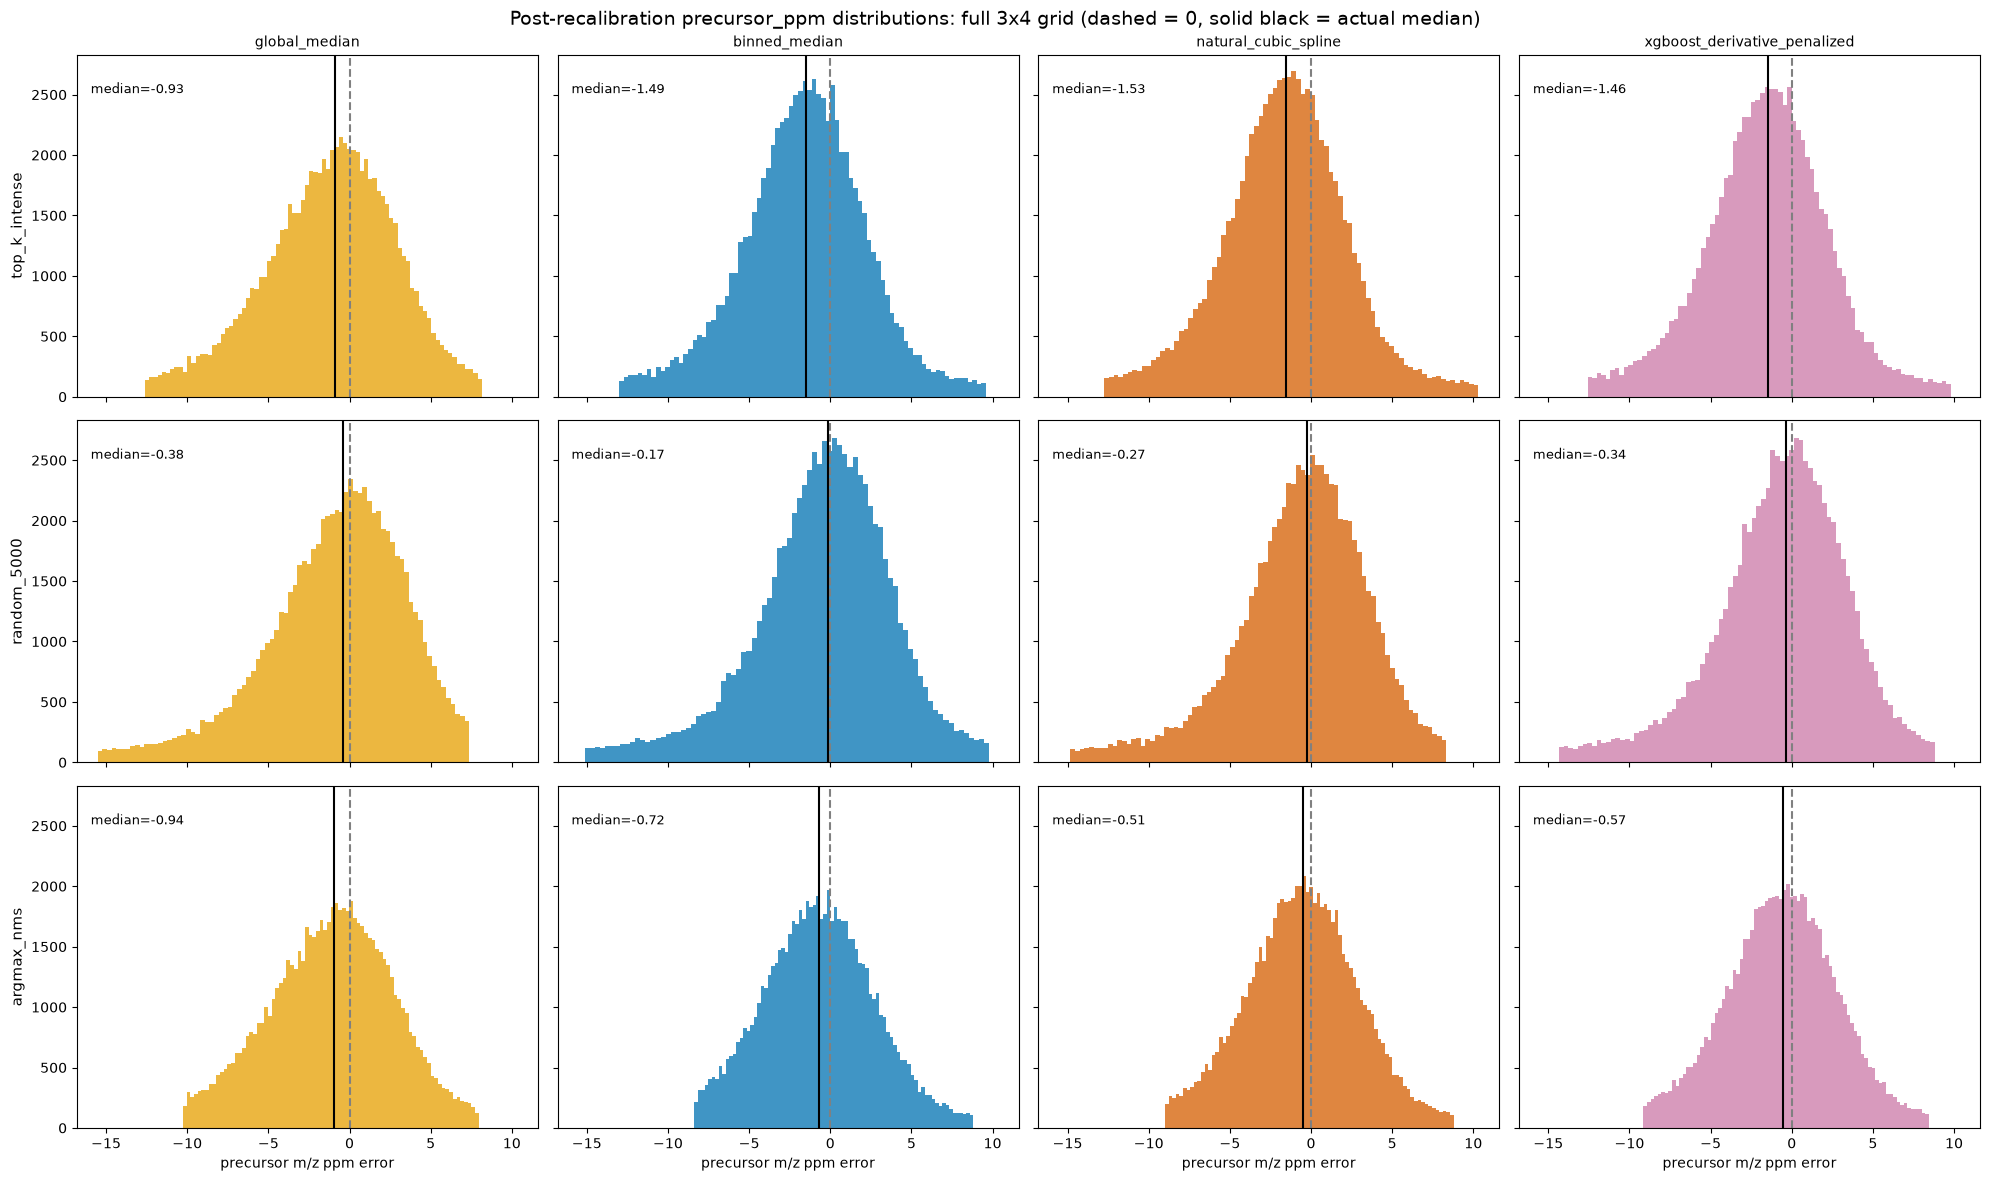

In [3]:
MODEL_COLORS = {
    "global_median": "#E69F00",
    "binned_median": "#0072B2",
    "natural_cubic_spline": "#D55E00",
    "xgboost_derivative_penalized": "#CC79A7",
}

fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=True, sharey=True)

for row, selection in enumerate(SELECTIONS):
    for col, model in enumerate(MODELS):
        ax = axes[row, col]
        ppm = dfs[(selection, model)]["precursor_ppm"]
        median = ppm.median()

        ax.hist(ppm, bins=80, color=MODEL_COLORS[model], alpha=0.75, linewidth=0)
        ax.axvline(0, color="#808080", linewidth=1.5, linestyle="--")
        ax.axvline(median, color="black", linewidth=1.5)
        ax.text(
            0.03, 0.92, f"median={median:.2f}", transform=ax.transAxes,
            fontsize=9, va="top",
        )

        if row == 0:
            ax.set_title(model, fontsize=10)
        if col == 0:
            ax.set_ylabel(selection, fontsize=11)
        if row == 2:
            ax.set_xlabel("precursor m/z ppm error")

fig.suptitle(
    "Post-recalibration precursor_ppm distributions: full 3x4 grid "
    "(dashed = 0, solid black = actual median)",
    fontsize=14,
)
fig.tight_layout()
plt.show()


## All 12 overlaid: KDE comparison

Same data, overlaid as smooth density curves (color = selection strategy,
linestyle = correction model) so the selection-driven offset clusters (visible in
`grid_summary` as three distinct bands) can be compared directly in one view.


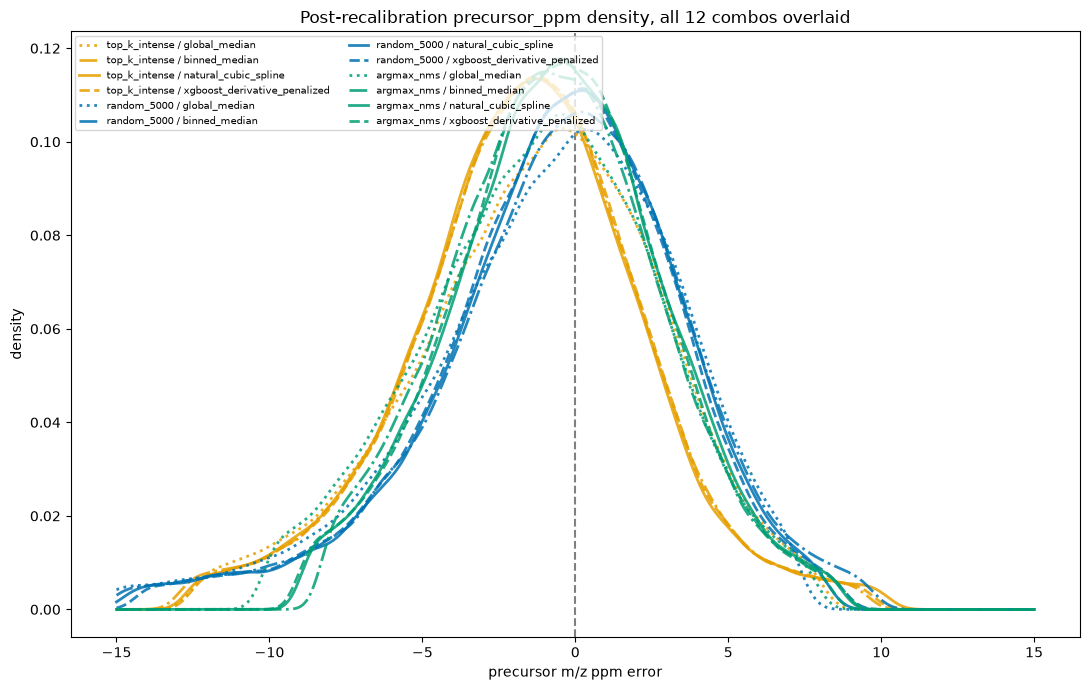

In [4]:
from scipy.stats import gaussian_kde

SELECTION_COLORS = {
    "top_k_intense": "#E69F00",
    "random_5000": "#0072B2",
    "argmax_nms": "#009E73",
}
MODEL_LINESTYLES = {
    "global_median": ":",
    "binned_median": "-.",
    "natural_cubic_spline": "-",
    "xgboost_derivative_penalized": "--",
}

x_grid = np.linspace(-15, 15, 400)

fig, ax = plt.subplots(figsize=(11, 7))
for selection in SELECTIONS:
    for model in MODELS:
        ppm = dfs[(selection, model)]["precursor_ppm"].to_numpy()
        density = gaussian_kde(ppm)(x_grid)
        ax.plot(
            x_grid, density,
            color=SELECTION_COLORS[selection], linestyle=MODEL_LINESTYLES[model],
            linewidth=2, alpha=0.85, label=f"{selection} / {model}",
        )

ax.axvline(0, color="#808080", linewidth=1.5, linestyle="--", zorder=0)
ax.set_xlabel("precursor m/z ppm error")
ax.set_ylabel("density")
ax.legend(fontsize=7, ncol=2, loc="upper left")
ax.set_title("Post-recalibration precursor_ppm density, all 12 combos overlaid")
fig.tight_layout()
plt.show()


## `tolerance_percentiles` sensitivity, on the best-ion-yielding combo

`top_k_intense + natural_cubic_spline` had the highest `ion_count` (22,101) of all
12 grid combos. `jobs/short_test_recal_tol_grid.toml` reruns exactly that
selection+model pair with `[recalibration].tolerance_percentiles` swept across
`[0, 100]` (the baseline used everywhere else in this notebook -- full min/max of
the residual distribution, no trimming), `[0.5, 99.5]`, and `[1, 99]` -- i.e.
quantiles (0.005, 0.995) and (0.01, 0.99) on a 0-1 scale, trimming progressively
more of the residual tails before setting the final search's precursor/fragment
tolerance window.


In [5]:
tol_combos = nf_outputs("jobs/short_test_recal_tol_grid.toml")

def tol_label_parts(label):
    # "short_test_recal_tol_grid__recalibration_tolerance_percentiles+0p5-99p5"
    suffix = label.split("tolerance_percentiles+", 1)[1]
    return suffix.replace("p", ".")

tol_rows = []
for label, outputs in tol_combos.items():
    tol_setting = tol_label_parts(label)
    with open(REPO_ROOT / outputs["recalibration_tolerance"]) as _f:
        import json as _json
        applied = _json.load(_f)
    combo_df = filter_top_psms(REPO_ROOT / outputs["sage_results_tsv"], fdr=FDR)
    ppm = combo_df["precursor_ppm"]
    level = pd.read_csv(REPO_ROOT / outputs["sage_summary"], sep="\t").iloc[0]
    tol_rows.append({
        "tolerance_percentiles": tol_setting,
        "applied_precursor_tol_ppm": applied["precursor_tol"]["ppm"],
        "n_confident_psms": len(combo_df),
        "ppm_median": ppm.median(),
        "ppm_mad": (ppm - ppm.median()).abs().median(),
        "ppm_iqr": ppm.quantile(0.75) - ppm.quantile(0.25),
        "psm_count": level["psm_count"],
        "peptide_count": level["peptide_count"],
        "ion_count": level["ion_count"],
        "protein_count": level["protein_count"],
    })

tol_summary = pd.DataFrame(tol_rows).set_index("tolerance_percentiles").sort_index()
tol_summary


,applied_precursor_tol_ppm,n_confident_psms,ppm_median,ppm_mad,ppm_iqr,psm_count,peptide_count,ion_count,protein_count
tolerance_percentiles,,,,,,,,,
0-100,"[-10.24170447503057, 12.641905177184931]",80971,-1.525093,2.376357,4.761388,81334,19358,22101,3925
0.5-99.5,"[-6.614961819140579, 6.782329174977289]",64854,-1.236091,2.065878,4.130903,65138,17073,19117,3624
1-99,"[-5.8959203908992555, 5.822743401883879]",58391,-1.113056,1.938880,3.882113,58657,15974,17750,3504


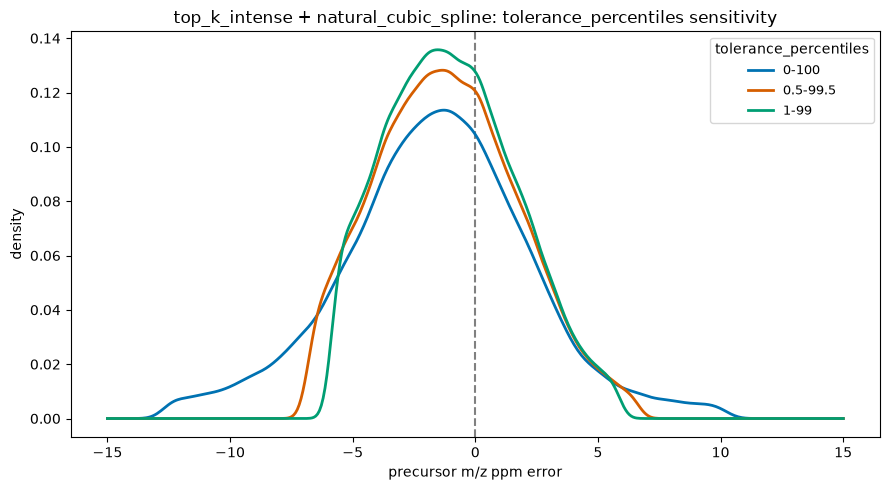

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
TOL_COLORS = {"0-100": "#0072B2", "0.5-99.5": "#D55E00", "1-99": "#009E73"}

for label, outputs in tol_combos.items():
    tol_setting = tol_label_parts(label)
    ppm = filter_top_psms(REPO_ROOT / outputs["sage_results_tsv"], fdr=FDR)["precursor_ppm"]
    density = gaussian_kde(ppm.to_numpy())(x_grid)
    ax.plot(x_grid, density, color=TOL_COLORS[tol_setting], linewidth=2, label=tol_setting)

ax.axvline(0, color="#808080", linewidth=1.5, linestyle="--", zorder=0)
ax.set_xlabel("precursor m/z ppm error")
ax.set_ylabel("density")
ax.legend(title="tolerance_percentiles", fontsize=9)
ax.set_title("top_k_intense + natural_cubic_spline: tolerance_percentiles sensitivity")
fig.tight_layout()
plt.show()


## Post-correction `precursor_ppm` vs. `precursor_mz`: full 3x4 grid

Same 12 combos as the histogram grid above, now as a scatter against `precursor_mz`
-- checks for leftover mz-dependent structure in the residual after recalibration
(a flat cloud around the median means the correction removed the trend; a residual
slope or curve means the fit under-corrected some part of the mz range).


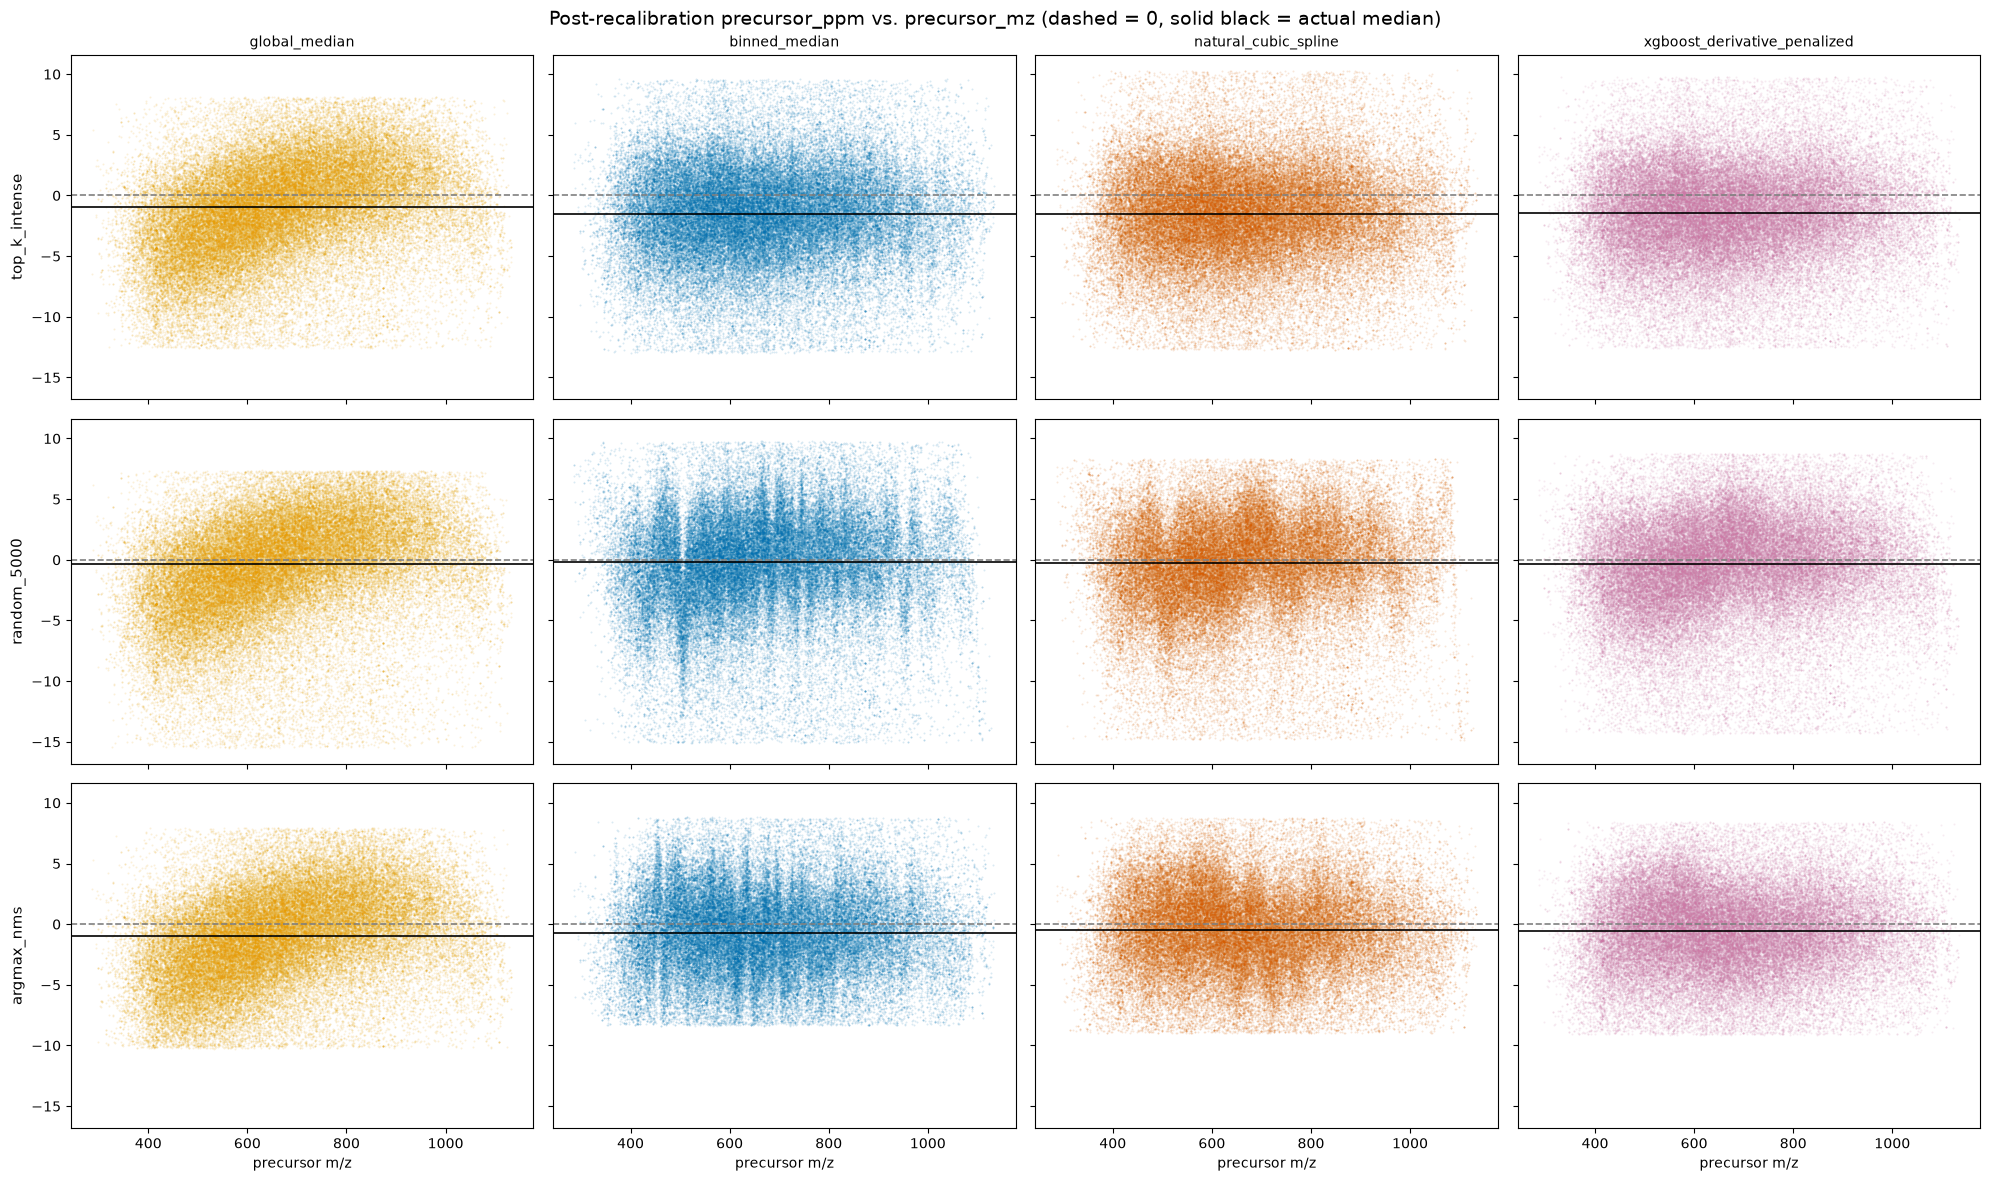

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex=True, sharey=True)

for row, selection in enumerate(SELECTIONS):
    for col, model in enumerate(MODELS):
        ax = axes[row, col]
        df = dfs[(selection, model)]
        ax.scatter(
            df["precursor_mz"], df["precursor_ppm"],
            s=2, alpha=0.15, color=MODEL_COLORS[model], linewidths=0,
        )
        ax.axhline(0, color="#808080", linewidth=1.2, linestyle="--")
        ax.axhline(df["precursor_ppm"].median(), color="black", linewidth=1.2)

        if row == 0:
            ax.set_title(model, fontsize=10)
        if col == 0:
            ax.set_ylabel(selection, fontsize=11)
        if row == 2:
            ax.set_xlabel("precursor m/z")

fig.suptitle(
    "Post-recalibration precursor_ppm vs. precursor_mz "
    "(dashed = 0, solid black = actual median)",
    fontsize=14,
)
fig.tight_layout()
plt.show()


## Post-correction `precursor_ppm` vs. `precursor_mz`: `tolerance_percentiles` sweep

Same check for the 3 `tolerance_percentiles` variants (`top_k_intense` +
`natural_cubic_spline`) -- does narrowing the tolerance window leave the mz-trend
looking any different, or just remove points uniformly across the range?


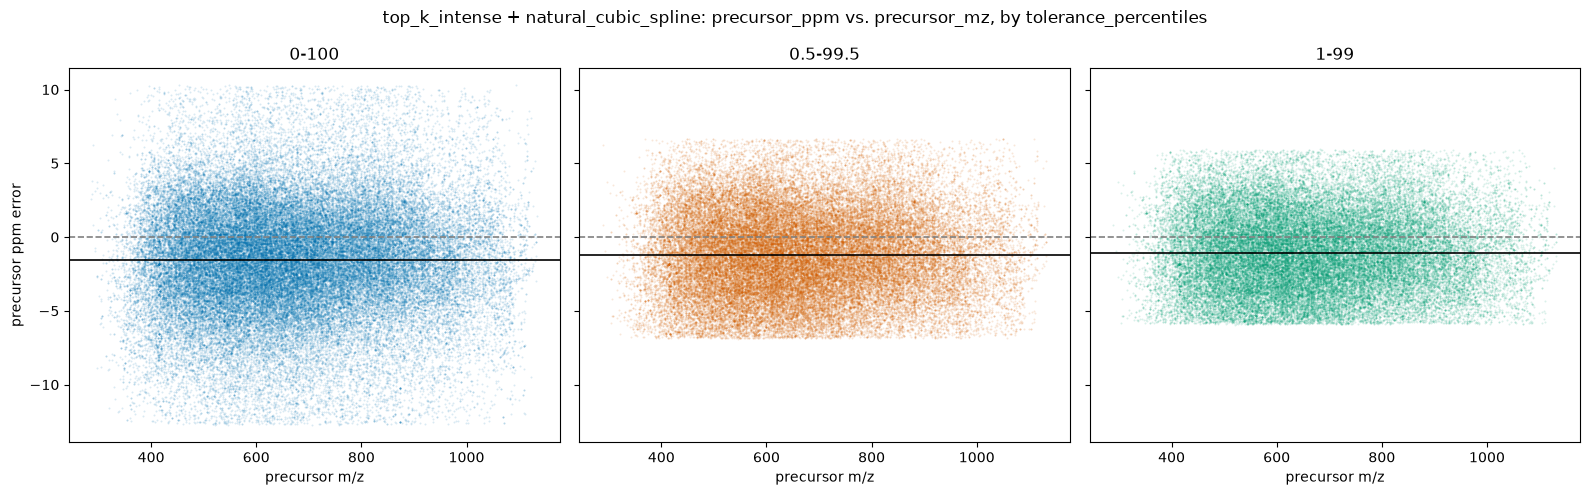

In [8]:
tol_dfs = {
    tol_label_parts(label): filter_top_psms(REPO_ROOT / outputs["sage_results_tsv"], fdr=FDR)
    for label, outputs in tol_combos.items()
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

for ax, tol_setting in zip(axes, ["0-100", "0.5-99.5", "1-99"]):
    df = tol_dfs[tol_setting]
    ax.scatter(
        df["precursor_mz"], df["precursor_ppm"],
        s=2, alpha=0.15, color=TOL_COLORS[tol_setting], linewidths=0,
    )
    ax.axhline(0, color="#808080", linewidth=1.2, linestyle="--")
    ax.axhline(df["precursor_ppm"].median(), color="black", linewidth=1.2)
    ax.set_title(tol_setting)
    ax.set_xlabel("precursor m/z")

axes[0].set_ylabel("precursor ppm error")
fig.suptitle(
    "top_k_intense + natural_cubic_spline: precursor_ppm vs. precursor_mz, "
    "by tolerance_percentiles"
)
fig.tight_layout()
plt.show()
